In [4]:
from datasets import load_dataset

/Users/kento/Desktop/Projects/nlp/text-to-sql/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
dataset = load_dataset('b-mc2/sql-create-context')

Generating train split: 100%|██████████| 78577/78577 [00:00<00:00, 272706.22 examples/s]


In [9]:
dataset

DatasetDict({
    train: Dataset({
        features: ['answer', 'question', 'context'],
        num_rows: 78577
    })
})

In [10]:
train_data = dataset['train']

In [17]:
train_data[0]

{'answer': 'SELECT COUNT(*) FROM head WHERE age > 56',
 'question': 'How many heads of the departments are older than 56 ?',
 'context': 'CREATE TABLE head (age INTEGER)'}

#### Query length distribution

(array([1.9600e+02, 3.2560e+03, 1.0386e+04, 1.4766e+04, 1.3333e+04,
        1.1076e+04, 8.6110e+03, 6.7080e+03, 3.9620e+03, 2.4040e+03,
        1.6710e+03, 9.1300e+02, 5.3700e+02, 2.8500e+02, 2.0900e+02,
        1.2700e+02, 6.0000e+01, 3.8000e+01, 1.1000e+01, 1.2000e+01,
        5.0000e+00, 5.0000e+00, 2.0000e+00, 1.0000e+00, 3.0000e+00]),
 array([ 12.  ,  21.28,  30.56,  39.84,  49.12,  58.4 ,  67.68,  76.96,
         86.24,  95.52, 104.8 , 114.08, 123.36, 132.64, 141.92, 151.2 ,
        160.48, 169.76, 179.04, 188.32, 197.6 , 206.88, 216.16, 225.44,
        234.72, 244.  ]),
 <BarContainer object of 25 artists>)

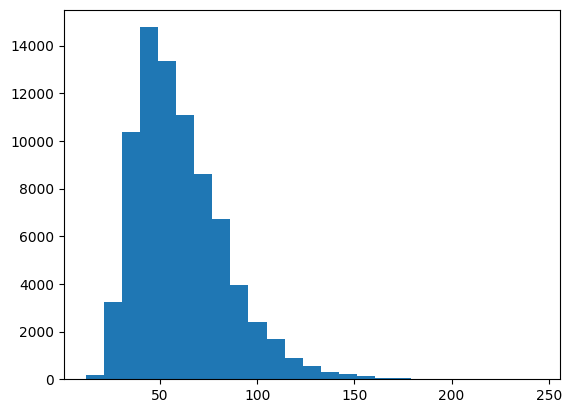

In [29]:
import matplotlib.pyplot as plt

lengths = [len(x['question']) for x in train_data]

plt.hist(lengths, bins=25)

#### Query difficulty

In [33]:
join_count = sum('JOIN' in x['answer'].upper() for x in train_data)
groupby_count = sum('GROUP BY' in x['answer'].upper() for x in train_data)
print(join_count, groupby_count)


1931 1160
